In [30]:
tracking_errors = []

for code in top5["amfi_code"]:

    fund_ret = daily_returns[
        daily_returns["amfi_code"] == code
    ]

    merged = pd.merge(
        fund_ret,
        nifty[
            ["date", "benchmark_return"]
        ],
        on="date",
        how="inner"
    )

    te = (
        (
            merged["daily_return"]
            -
            merged["benchmark_return"]
        )
        .std()
        *
        np.sqrt(252)
    )

    tracking_errors.append(
        [code, te]
    )

tracking_df = pd.DataFrame(
    tracking_errors,
    columns=[
        "amfi_code",
        "tracking_error"
    ]
)

tracking_df

,amfi_code,tracking_error
0,101208,0.128957
1,119092,0.189082
2,100016,0.199284
3,119120,0.135646
4,118636,0.134758


# tracking error

In [29]:
top5 = (
    scorecard
    .sort_values(
        "fund_score",
        ascending=False
    )
    .head(5)
)

top5[["amfi_code", "fund_score"]]

,amfi_code,fund_score
5,101208,100.000000
14,119092,99.651972
0,100016,95.359629
18,119120,94.199536
13,118636,92.575406


# benchmark coparison chart

In [27]:
#merging all matrix

scorecard = (
    cagr_df
    .merge(sharpe_df, on="amfi_code")
    .merge(alpha_beta_df, on="amfi_code")
    .merge(drawdown_df, on="amfi_code")
)

# add expense ratio

expense = performance[
    ["amfi_code", "expense_ratio_pct"]
]

scorecard = scorecard.merge(
    expense,
    on="amfi_code",
    how="left"
)

'''Create Rankings

Higher is better for:

CAGR
Sharpe
Alpha

Lower is better for:

Expense Ratio
Drawdown'''

scorecard["return_rank"] = (
    scorecard["cagr"]
    .rank(ascending=False)
)

scorecard["sharpe_rank"] = (
    scorecard["sharpe_ratio"]
    .rank(ascending=False)
)

scorecard["alpha_rank"] = (
    scorecard["alpha"]
    .rank(ascending=False)
)

scorecard["expense_rank"] = (
    scorecard["expense_ratio_pct"]
    .rank(ascending=True)
)

scorecard["drawdown_rank"] = (
    scorecard["max_drawdown"]
    .rank(ascending=False)
)

# calculating composite score

scorecard = scorecard.merge(
    performance[
        ["amfi_code", "return_3yr_pct"]
    ],
    on="amfi_code",
    how="left"
)

scorecard["return_rank"] = (
    scorecard["return_3yr_pct"]
    .rank(ascending=False)
)

scorecard["raw_score"] = (

    0.30 * scorecard["return_rank"] +

    0.25 * scorecard["sharpe_rank"] +

    0.20 * scorecard["alpha_rank"] +

    0.15 * scorecard["expense_rank"] +

    0.10 * scorecard["drawdown_rank"]

)

#Convert to 0–100 Scale

scorecard["fund_score"] = 100 * (

    scorecard["raw_score"]
    -
    scorecard["raw_score"].min()

) / (

    scorecard["raw_score"].max()
    -
    scorecard["raw_score"].min()

)

# top funds

scorecard = scorecard.sort_values(
    "fund_score",
    ascending=False
)

scorecard.head(10)

#save
scorecard.to_csv(
    "../data/processed/fund_scorecard.csv",
    index=False
)


In [28]:
print(performance.columns.tolist())

['amfi_code', 'scheme_name', 'fund_house', 'category', 'plan', 'return_1yr_pct', 'return_3yr_pct', 'return_5yr_pct', 'benchmark_3yr_pct', 'alpha', 'beta', 'sharpe_ratio', 'sortino_ratio', 'std_dev_ann_pct', 'max_drawdown_pct', 'aum_crore', 'expense_ratio_pct', 'morningstar_rating', 'risk_grade']


# fnd scorecard

In [ ]:

def max_drawdown(nav_series):
    
    running_max = nav_series.cummax()

    drawdown = (
        nav_series /
        running_max
    ) - 1

    return drawdown.min()

drawdowns = []

for code, grp in nav.groupby("amfi_code"):

    grp = grp.sort_values("date")

    mdd = max_drawdown(
        grp["nav"]
    )

    drawdowns.append([
        code,
        mdd
    ])

drawdown_df = pd.DataFrame(
    drawdowns,
    columns=[
        "amfi_code",
        "max_drawdown"
    ]
)

drawdown_df.head()

drawdown_df.sort_values(
    "max_drawdown"
).head(10)

drawdown_df.to_csv(
    "../data/processed/max_drawdown.csv",
    index=False
)

# max drawdown

In [22]:
nifty = benchmark[
    benchmark["index_name"] == "NIFTY100"
].copy()

nifty["date"] = pd.to_datetime(nifty["date"])

nifty = nifty.sort_values("date")

nifty["benchmark_return"] = (
    nifty["close_value"]
    .pct_change()
)

from scipy.stats import linregress

alpha_beta = []

for code, grp in daily_returns.groupby("amfi_code"):

    merged = pd.merge(
        grp,
        nifty[["date", "benchmark_return"]],
        on="date",
        how="inner"
    ).dropna()

    if len(merged) < 30:
        continue

    slope, intercept, r_value, p_value, std_err = linregress(
        merged["benchmark_return"],
        merged["daily_return"]
    )

    alpha_beta.append([
        code,
        intercept * 252,   # annualized alpha
        slope              # beta
    ])

alpha_beta_df = pd.DataFrame(
    alpha_beta,
    columns=[
        "amfi_code",
        "alpha",
        "beta"
    ]
)

alpha_beta_df.head()

alpha_beta_df.to_csv(
    "../data/processed/alpha_beta.csv",
    index=False
)

In [20]:
benchmark["index_name"].unique()

<StringArray>
[        'NIFTY50',        'NIFTY100', 'NIFTY_MIDCAP150',    'BSE_SMALLCAP',
        'NIFTY500',   'CRISIL_LIQUID',     'CRISIL_GILT']
Length: 7, dtype: str

# alpha and beta

In [19]:
sortino_results = []

for code, grp in daily_returns.groupby(
    "amfi_code"
):

    downside = grp[
        grp["daily_return"] < 0
    ]

    downside_std = downside[
        "daily_return"
    ].std()

    annual_return = (
        grp["daily_return"].mean()
        *252
    )

    sortino = (
        (annual_return-rf)
        /
        downside_std
    ) * np.sqrt(252)

    sortino_results.append([
        code,
        sortino
    ])

sortino_df = pd.DataFrame(
    sortino_results,
    columns=["amfi_code","sortino_ratio"]
)

# sornito ratio

In [17]:
rf = 0.065

sharpe_results = []

for code, grp in daily_returns.groupby(
    "amfi_code"
):

    mean_return = grp["daily_return"].mean()*252

    std_return = grp["daily_return"].std()

    sharpe = (
        (mean_return-rf)
        /
        std_return
    ) * np.sqrt(252)

    sharpe_results.append([
        code,
        sharpe
    ])

sharpe_df = pd.DataFrame(
    sharpe_results,
    columns=["amfi_code","sharpe_ratio"]
)

# sharpe ratio

In [16]:
cagr_results = []

for code, group in nav.groupby("amfi_code"):

    cagr = calculate_cagr(group)

    cagr_results.append([
        code,
        cagr
    ])

cagr_df = pd.DataFrame(
    cagr_results,
    columns=["amfi_code","cagr"]
)

cagr_df.to_csv(
    "../data/processed/cagr_table.csv",
    index=False
)

# compute sagar

In [15]:
def calculate_cagr(df):
    
    start_nav = df.iloc[0]["nav"]
    end_nav = df.iloc[-1]["nav"]

    years = (
        (df.iloc[-1]["date"] -
         df.iloc[0]["date"]).days
    ) / 365

    return (
        (end_nav/start_nav)
        ** (1/years)
        - 1
    )

# CGAR function

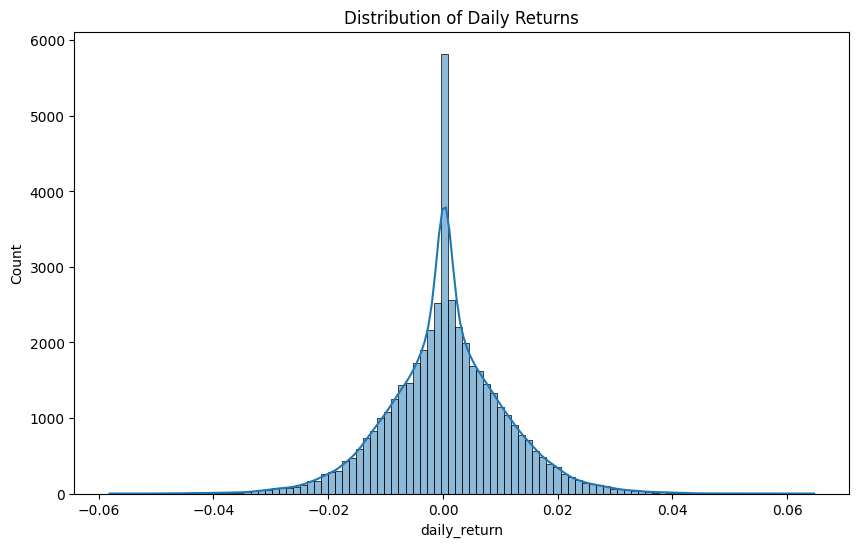

In [14]:
plt.figure(figsize=(10,6))

sns.histplot(
    daily_returns["daily_return"],
    bins=100,
    kde=True
)

plt.title("Distribution of Daily Returns")

plt.show()

# distribution check

In [11]:
nav = nav.sort_values(
    ["amfi_code","date"]
)

nav["daily_return"] = (
    nav.groupby("amfi_code")["nav"]
       .pct_change()
)

daily_returns = nav.dropna()

daily_returns.to_csv(
    "../data/processed/daily_returns.csv",
    index=False
)

# daily returns

In [8]:
nav = pd.read_csv(
    "../data/processed/nav_history_clean.csv"
)

benchmark = pd.read_csv(
    "../data/processed/benchmark_indices_clean.csv"
)

fund = pd.read_csv(
    "../data/processed/fund_master_clean.csv"
)

performance = pd.read_csv(
    "../data/processed/scheme_performance_clean.csv"
)

nav["date"] = pd.to_datetime(nav["date"])
benchmark["date"] = pd.to_datetime(benchmark["date"])

# dataset reading

In [6]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from scipy.stats import linregress

# Fund Performance Analytics